## Домашка 1
#### *«Великаны — как луковицы. Лук многослоен! Я тоже! Слой за слоем. Ты усёк? Мы многослойные!» — Шрек*

Эта домашка про декомпозицию и срезы. За неё можно получить максимум 6 баллов. На решение отводится **14 календарных дней** с момента выдачи. Обратите внимание, что **дедлайны на курсе сразу жёсткие**, а значит отправка решений после них запрещена.
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.    

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета. 
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в [ведомости](https://docs.google.com/spreadsheets/d/13lHNf6xU6tZhqzVMAb8sV3RgyyDatepwo7FJ6FhZ0vY/edit?usp=sharing) на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_1). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3. 

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_1_data.zip)

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

### Case Study. Что-то пошло не так в маркетплейсе 🛒

**Легенда**  
Вы работаете продуктовым аналитиком в маркетплейсе. Ваша команда отвечает за функционал корзины — точки входа, дизайн и функционал самой корзины, путь пользователя с момента добавления товара в корзину и до оформления покупки. 

Компания — стартап без системы автоматического мониторинга. Поэтому последние 14 дней, пока вы были в отпуске, никто не следил за метриками корзины. 

Вы отлично отдохнули и в первый же день после каникул рвётесь в бой. Наливаете чашку кофе, открываете ноутбук и проверяете, что творилось в ваше отсутствие.

In [3]:
df = pd.read_parquet('data/hw_1_marketplace_data.parquet')

In [4]:
df.head()

,user_id,session_id,event_ts,platform,app_version,region,channel,category,event,product_id,price,quantity
0,30,1094418511,2025-04-01 19:49:57,Desktop,web,siberia,ads_search,None,search,NaN,NaN,NaN
1,30,1094418511,2025-04-01 20:02:23,Desktop,web,siberia,ads_search,electronics,view_item,123443.0,NaN,NaN
2,30,1094418511,2025-04-01 20:22:53,Desktop,web,siberia,ads_search,fashion,view_item,162950.0,NaN,NaN
3,30,1094418511,2025-04-01 20:40:57,Desktop,web,siberia,ads_search,home,view_item,199979.0,NaN,NaN
4,30,1094418511,2025-04-01 20:41:07,Desktop,web,siberia,ads_search,home,add_to_cart,199979.0,NaN,NaN


Описание данных

- user_id — уникальный идентификатор пользователя
- session_id — уникальный идентификатор сессии
- event_ts — таймстемп событий
- platform — платформа, с которой пришло событие
- app_version — версия приложения (существует только для iOS и Android, для остальных платформ приходят значения-заглушки)
- region — регион пользователя
- channel — канал, с которого пришел пользователь
- category — категория товаров, которой принадлежит ивент
- event — событие, совершенное пользователем
- product_id — идентификатор товара для событий над товарами
- price — цена товара, ивент приходит только для события покупки
- quantity — количество товаров, ивент приходит только для события покупки

#### **1. Детекция проблемы — 1 балл**

1) Посчитайте подневные конверсии: из просмотра в покупку, из просмотра в добавление в корзину, из добавления в корзину — в покупку.
2) Визуализируйте полученную динамику. 
3) Опишите, что вы видите на графике: когда и в каких метриках началось падение? есть ли устойчивый тренд?

*К подсчёту конверсий можно подойти разными способами — считать их по событиям, сессиям или уникальным юзерам. В нашей задаче будем считать по сессиям.*

In [5]:

df['date'] = pd.to_datetime(df['event_ts']).dt.date

print("Размер данных:", df.shape)
print("\nУникальные события:")
print(df['event'].value_counts())
print("\nПериод данных: от", df['date'].min(), "до", df['date'].max())

Размер данных: (266831, 13)

Уникальные события:
event
view_item           162302
search               42144
add_to_cart          31738
add_to_favorites     19949
purchase              7381
remove_from_cart      3317
Name: count, dtype: int64

Период данных: от 2025-04-01 до 2025-04-30


In [6]:
# Расчет конверсий по сессиям
sessions_events = df.groupby(['date', 'session_id'])['event'].apply(lambda x: set(x)).reset_index()
sessions_events.columns = ['date', 'session_id', 'events_set']

sessions_events['has_view'] = sessions_events['events_set'].apply(lambda x: 'view_item' in x)
sessions_events['has_cart'] = sessions_events['events_set'].apply(lambda x: 'add_to_cart' in x) 
sessions_events['has_purchase'] = sessions_events['events_set'].apply(lambda x: 'purchase' in x)

In [7]:
# Агрегация по дням
daily_funnel = sessions_events.groupby('date').agg({
    'has_view': 'sum',
    'has_cart': 'sum',
    'has_purchase': 'sum'
}).reset_index()

daily_funnel.columns = ['date', 'sessions_with_view', 'sessions_with_cart', 'sessions_with_purchase']

# Расчет конверсий
daily_funnel['cr_view_to_purchase'] = (daily_funnel['sessions_with_purchase'] / daily_funnel['sessions_with_view'] * 100).round(2)
daily_funnel['cr_view_to_cart'] = (daily_funnel['sessions_with_cart'] / daily_funnel['sessions_with_view'] * 100).round(2)
daily_funnel['cr_cart_to_purchase'] = (daily_funnel['sessions_with_purchase'] / daily_funnel['sessions_with_cart'] * 100).round(2)


daily_funnel.head()


,date,sessions_with_view,sessions_with_cart,sessions_with_purchase,cr_view_to_purchase,cr_view_to_cart,cr_cart_to_purchase
0,2025-04-01,1949,633,209,10.72,32.48,33.02
1,2025-04-02,2092,677,208,9.94,32.36,30.72
2,2025-04-03,2124,668,201,9.46,31.45,30.09
3,2025-04-04,2291,764,215,9.38,33.35,28.14
4,2025-04-05,3187,1049,337,10.57,32.91,32.13


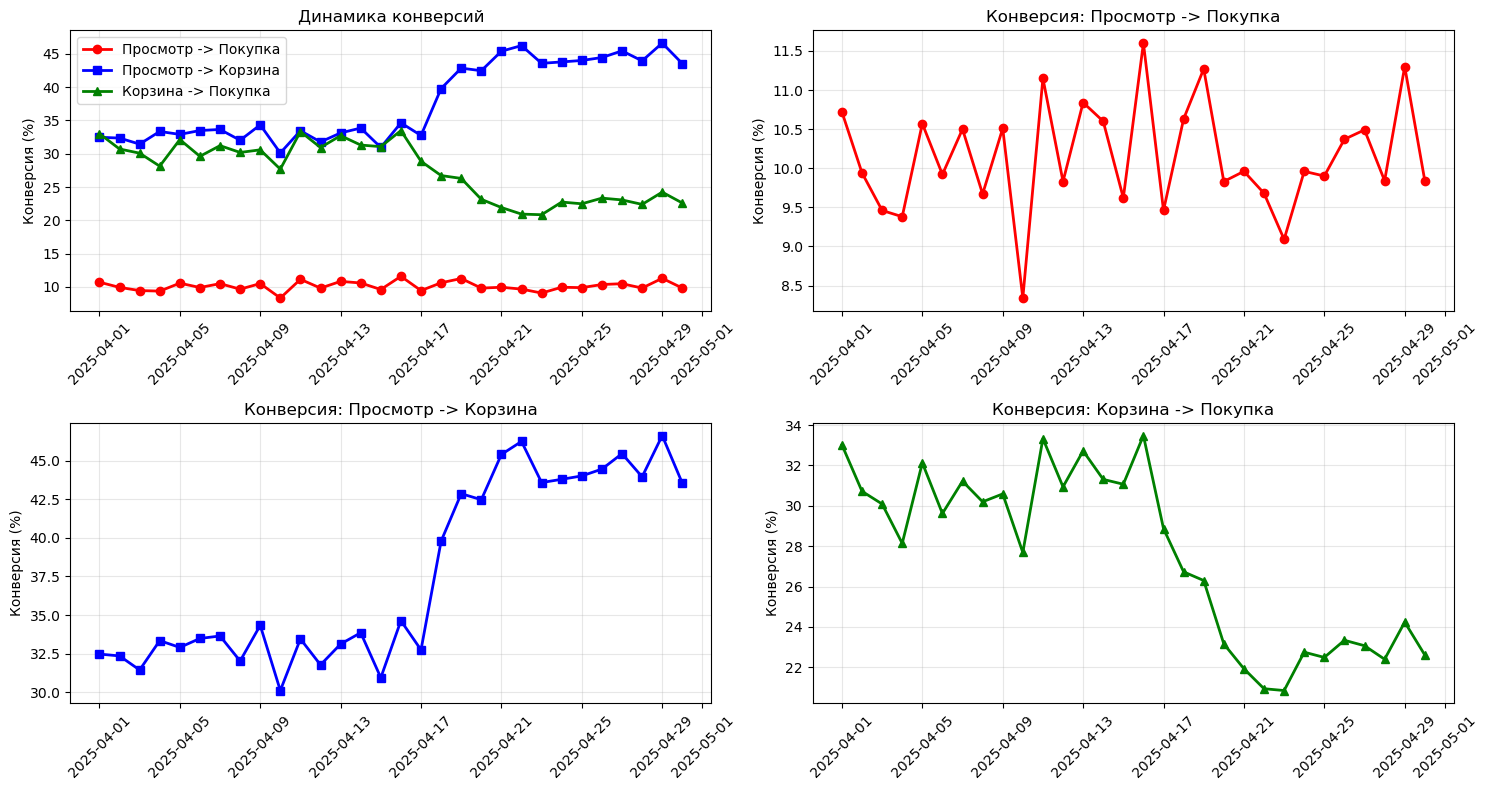

In [8]:
# Визуализация конверсий
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.plot(daily_funnel['date'], daily_funnel['cr_view_to_purchase'], marker='o', linewidth=2, label='Просмотр -> Покупка', color='red')
plt.plot(daily_funnel['date'], daily_funnel['cr_view_to_cart'], marker='s', linewidth=2, label='Просмотр -> Корзина', color='blue') 
plt.plot(daily_funnel['date'], daily_funnel['cr_cart_to_purchase'], marker='^', linewidth=2, label='Корзина -> Покупка', color='green')
plt.title('Динамика конверсий')
plt.ylabel('Конверсия (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
plt.plot(daily_funnel['date'], daily_funnel['cr_view_to_purchase'], marker='o', linewidth=2, color='red')
plt.title('Конверсия: Просмотр -> Покупка')
plt.ylabel('Конверсия (%)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
plt.plot(daily_funnel['date'], daily_funnel['cr_view_to_cart'], marker='s', linewidth=2, color='blue')
plt.title('Конверсия: Просмотр -> Корзина')
plt.ylabel('Конверсия (%)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
plt.plot(daily_funnel['date'], daily_funnel['cr_cart_to_purchase'], marker='^', linewidth=2, color='green')
plt.title('Конверсия: Корзина -> Покупка')
plt.ylabel('Конверсия (%)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [39]:
# Анализ изменений
cutoff_date = pd.to_datetime('2025-04-17').date()
before_issue = daily_funnel[daily_funnel['date'] < cutoff_date]
after_issue = daily_funnel[daily_funnel['date'] >= cutoff_date]

print("Анализ изменений до и после 17 апреля:")
print()
print("До проблемы (1-16 апреля):")
print(f"  Просмотр -> Покупка: {before_issue['cr_view_to_purchase'].mean():.2f}%")
print(f"  Просмотр -> Корзина: {before_issue['cr_view_to_cart'].mean():.2f}%")
print(f"  Корзина -> Покупка: {before_issue['cr_cart_to_purchase'].mean():.2f}%")

print("\nПосле проблемы (17-30 апреля):")
print(f"  Просмотр -> Покупка: {after_issue['cr_view_to_purchase'].mean():.2f}%")
print(f"  Просмотр -> Корзина: {after_issue['cr_view_to_cart'].mean():.2f}%")
print(f"  Корзина -> Покупка: {after_issue['cr_cart_to_purchase'].mean():.2f}%")

print("\nИзменения:")
view_to_purchase_change = ((after_issue['cr_view_to_purchase'].mean() - before_issue['cr_view_to_purchase'].mean()) / before_issue['cr_view_to_purchase'].mean() * 100)
view_to_cart_change = ((after_issue['cr_view_to_cart'].mean() - before_issue['cr_view_to_cart'].mean()) / before_issue['cr_view_to_cart'].mean() * 100)
cart_to_purchase_change = ((after_issue['cr_cart_to_purchase'].mean() - before_issue['cr_cart_to_purchase'].mean()) / before_issue['cr_cart_to_purchase'].mean() * 100)

print(f"  Просмотр -> Покупка: {view_to_purchase_change:+.1f}%")
print(f"  Просмотр -> Корзина: {view_to_cart_change:+.1f}%")
print(f"  Корзина -> Покупка: {cart_to_purchase_change:.1f}%")

Анализ изменений до и после 17 апреля:

До проблемы (1-16 апреля):
  Просмотр -> Покупка: 10.17%
  Просмотр -> Корзина: 32.75%
  Корзина -> Покупка: 31.02%

После проблемы (17-30 апреля):
  Просмотр -> Покупка: 10.12%
  Просмотр -> Корзина: 43.21%
  Корзина -> Покупка: 23.55%

Изменения:
  Просмотр -> Покупка: -0.5%
  Просмотр -> Корзина: +31.9%
  Корзина -> Покупка: -24.1%


Гипотеза: Около 17 апреля что-то сломалось в процессе оформления заказа или
  оплаты. Возможно, баг в чекауте, проблемы с платежной системой, или
  UX-проблема на последнем этапе покупки.

#### **2. Проверка абсолютных и средних значений — 1 балл**

1) Постройте графики дневной динамики абсолютных значений, из которых рассчитаны конверсии выше.
2) Рассчитайте и визуализируйте среднее число событий (именно событий, не сессий), из которых рассчитаны конверсии, на пользователя. 
3) На каком этапе воронки появилась проблема?

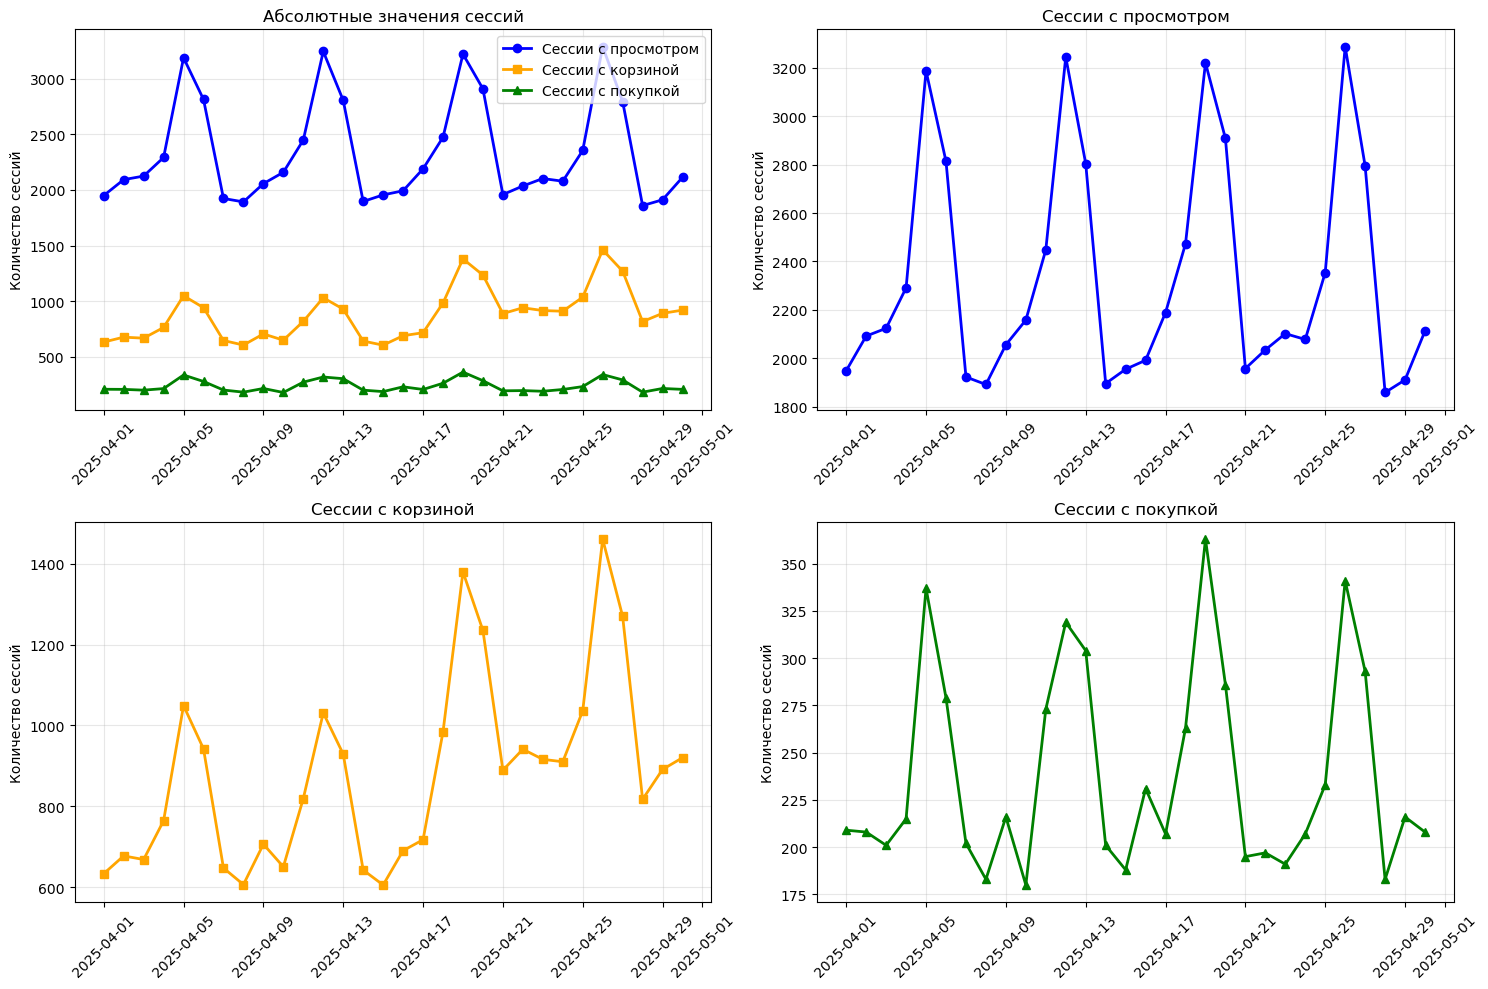

In [10]:


fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# График 1: Все абсолютные значения
axes[0, 0].plot(daily_funnel['date'], daily_funnel['sessions_with_view'], marker='o', linewidth=2, label='Сессии с просмотром', color='blue')
axes[0, 0].plot(daily_funnel['date'], daily_funnel['sessions_with_cart'], marker='s', linewidth=2, label='Сессии с корзиной', color='orange')
axes[0, 0].plot(daily_funnel['date'], daily_funnel['sessions_with_purchase'], marker='^', linewidth=2, label='Сессии с покупкой', color='green')
axes[0, 0].set_title('Абсолютные значения сессий')
axes[0, 0].set_ylabel('Количество сессий')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# График 2: Сессии с просмотром
axes[0, 1].plot(daily_funnel['date'], daily_funnel['sessions_with_view'], marker='o', linewidth=2, color='blue')
axes[0, 1].set_title('Сессии с просмотром')
axes[0, 1].set_ylabel('Количество сессий')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# График 3: Сессии с корзиной
axes[1, 0].plot(daily_funnel['date'], daily_funnel['sessions_with_cart'], marker='s', linewidth=2, color='orange')
axes[1, 0].set_title('Сессии с корзиной')
axes[1, 0].set_ylabel('Количество сессий')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# График 4: Сессии с покупкой
axes[1, 1].plot(daily_funnel['date'], daily_funnel['sessions_with_purchase'], marker='^', linewidth=2, color='green')
axes[1, 1].set_title('Сессии с покупкой')
axes[1, 1].set_ylabel('Количество сессий')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [37]:
# Расчет событий на пользователя
daily_events = df.groupby('date').agg({
    'user_id': 'nunique',
    'event': 'count'
}).reset_index()
daily_events.columns = ['date', 'unique_users', 'total_events']

# События по типам
daily_events_by_type = df.groupby(['date', 'event']).size().reset_index(name='count')
daily_events_pivot = daily_events_by_type.pivot(index='date', columns='event', values='count').fillna(0)

# Объединяем данные
daily_metrics = daily_events.merge(daily_events_pivot, on='date', how='left')

# Среднее на пользователя
daily_metrics['avg_views_per_user'] = daily_metrics['view_item'] / daily_metrics['unique_users']
daily_metrics['avg_cart_per_user'] = daily_metrics['add_to_cart'] / daily_metrics['unique_users']
daily_metrics['avg_purchase_per_user'] = daily_metrics['purchase'] / daily_metrics['unique_users']


daily_metrics[['date', 'unique_users', 'avg_views_per_user', 'avg_cart_per_user', 'avg_purchase_per_user']].head()

,date,unique_users,avg_views_per_user,avg_cart_per_user,avg_purchase_per_user
0,2025-04-01,1581,2.853890,0.461101,0.137887
1,2025-04-02,1629,2.967465,0.468386,0.130755
2,2025-04-03,1647,2.978142,0.472374,0.125683
3,2025-04-04,1794,2.969900,0.483278,0.126533
4,2025-04-05,2246,3.284951,0.543188,0.155833


Выводы по пункту 2: На каком этапе воронки возникла проблема?

Мы видим, что в целом пользователи продолжают активно взаимодействовать с сайтом:

просмотры товаров остаются на прежнем уровне,

корзину стали использовать даже чаще (+45% добавлений),

но количество покупок почти не изменилось.

То есть интерес к товарам есть, люди складывают их в корзину, но дальше процесс обрывается.

Иными словами, проблема явно на финальном шаге — при переходе из корзины к покупке. После 17 апреля, скорее всего, что-то изменилось именно в процессе оформления заказа или оплаты. Пользователи доходят до финала, но не могут или не хотят завершить сделку.

#### **3. Базовые срезы — 1 балл**
1. Постройте динамику проблемного события в разрезе:
- платформ,
- регионов,
- источников трафика,
- категорий товаров.

2. Есть ли выделяющийся срез?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

In [13]:

platform_cart = df[df['event'] == 'add_to_cart'].groupby(['date', 'platform']).size().reset_index(name='cart_events')
platform_users = df.groupby(['date', 'platform'])['user_id'].nunique().reset_index(name='users')
platform_data = platform_cart.merge(platform_users, on=['date', 'platform'])
platform_data['cart_per_user'] = platform_data['cart_events'] / platform_data['users']


platform_data.head()

,date,platform,cart_events,users,cart_per_user
0,2025-04-01,Android,410,881,0.465380
1,2025-04-01,Desktop,113,276,0.409420
2,2025-04-01,Mobile,53,99,0.535354
3,2025-04-01,iOS,153,325,0.470769
4,2025-04-02,Android,394,865,0.455491


In [14]:
# Подготовка данных по регионам
region_cart = df[df['event'] == 'add_to_cart'].groupby(['date', 'region']).size().reset_index(name='cart_events')
region_users = df.groupby(['date', 'region'])['user_id'].nunique().reset_index(name='users')
region_data = region_cart.merge(region_users, on=['date', 'region'])
region_data['cart_per_user'] = region_data['cart_events'] / region_data['users']

region_data.head()

,date,region,cart_events,users,cart_per_user
0,2025-04-01,central,138,295,0.467797
1,2025-04-01,far_east,26,45,0.577778
2,2025-04-01,leningrad_oblast,28,56,0.500000
3,2025-04-01,moscow_city,138,287,0.480836
4,2025-04-01,moscow_oblast,68,169,0.402367


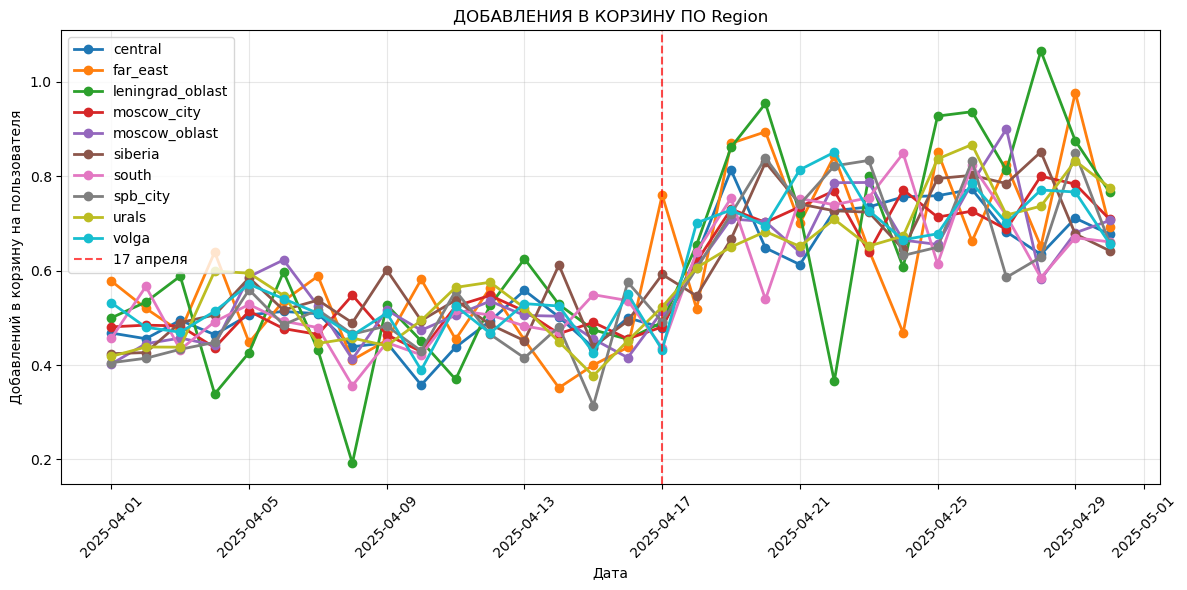

In [15]:
plt.figure(figsize=(12, 6))

regions = region_data['region'].unique()
for region in regions:
    data = region_data[region_data['region'] == region]
    plt.plot(data['date'], data['cart_per_user'], marker='o', label=region, linewidth=2)

plt.axvline(x=pd.to_datetime('2025-04-17').date(), color='red', linestyle='--', alpha=0.7, label='17 апреля')
plt.title('ДОБАВЛЕНИЯ В КОРЗИНУ ПО Region')
plt.xlabel('Дата')
plt.ylabel('Добавлений в корзину на пользователя')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Подготовка данных по источникам трафика
channel_cart = df[df['event'] == 'add_to_cart'].groupby(['date', 'channel']).size().reset_index(name='cart_events')
channel_users = df.groupby(['date', 'channel'])['user_id'].nunique().reset_index(name='users')
channel_data = channel_cart.merge(channel_users, on=['date', 'channel'])
channel_data['cart_per_user'] = channel_data['cart_events'] / channel_data['users']

channel_data.head()

,date,channel,cart_events,users,cart_per_user
0,2025-04-01,ads_search,153,318,0.481132
1,2025-04-01,ads_social,134,327,0.409786
2,2025-04-01,organic,410,867,0.472895
3,2025-04-01,referral,32,69,0.463768
4,2025-04-02,ads_search,141,283,0.498233


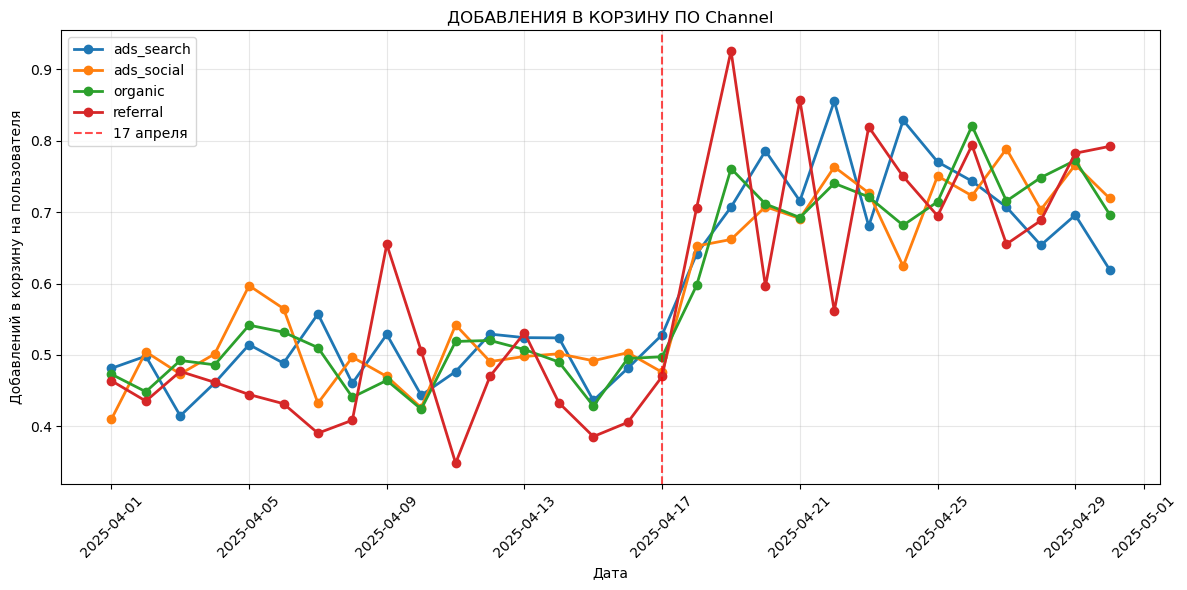

In [19]:
plt.figure(figsize=(12, 6))

channels = channel_data['channel'].unique()
for channel in channels:
    data = channel_data[channel_data['channel'] == channel]
    plt.plot(data['date'], data['cart_per_user'], marker='o', label=channel, linewidth=2)

plt.axvline(x=pd.to_datetime('2025-04-17').date(), color='red', linestyle='--', alpha=0.7, label='17 апреля')
plt.title('ДОБАВЛЕНИЯ В КОРЗИНУ ПО Channel')
plt.xlabel('Дата')
plt.ylabel('Добавлений в корзину на пользователя')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

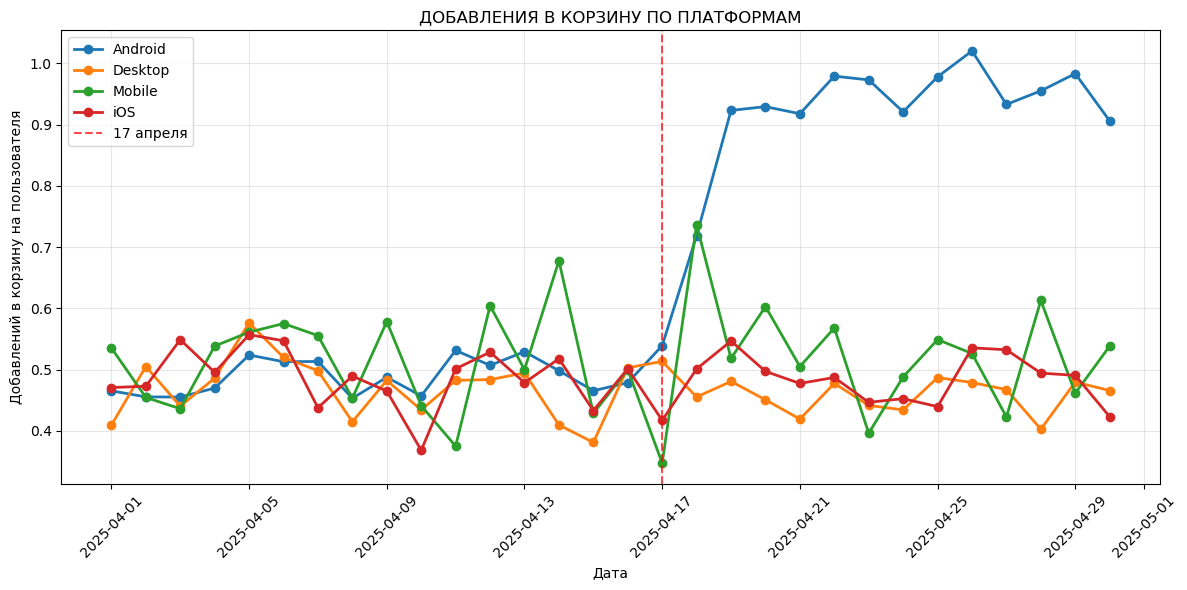

In [20]:
# График добавлений в корзину по платформам
plt.figure(figsize=(12, 6))

platforms = platform_data['platform'].unique()
for platform in platforms:
    data = platform_data[platform_data['platform'] == platform]
    plt.plot(data['date'], data['cart_per_user'], marker='o', label=platform, linewidth=2)

plt.axvline(x=pd.to_datetime('2025-04-17').date(), color='red', linestyle='--', alpha=0.7, label='17 апреля')
plt.title('ДОБАВЛЕНИЯ В КОРЗИНУ ПО ПЛАТФОРМАМ')
plt.xlabel('Дата')
plt.ylabel('Добавлений в корзину на пользователя')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

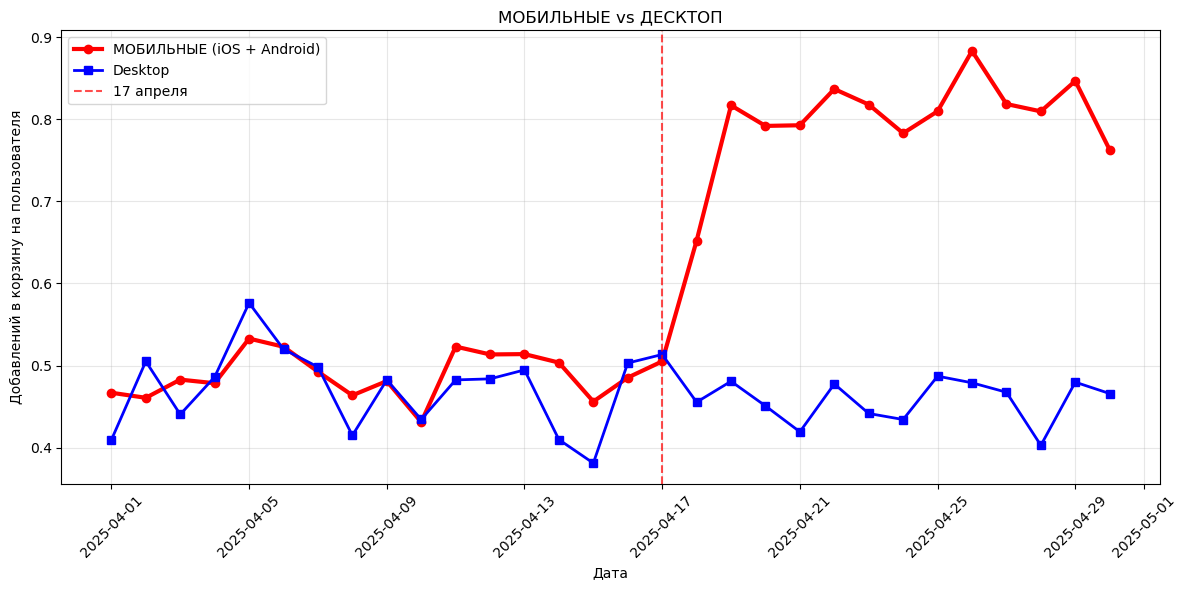

In [21]:
# Сравнение мобильных и десктоп платформ
mobile_data = platform_data[platform_data['platform'].isin(['iOS', 'Android'])]
desktop_data = platform_data[platform_data['platform'] == 'Desktop']

# Объединение мобильных данных
mobile_total = mobile_data.groupby('date').agg({
    'cart_events': 'sum',
    'users': 'sum'
}).reset_index()
mobile_total['cart_per_user'] = mobile_total['cart_events'] / mobile_total['users']

plt.figure(figsize=(12, 6))
plt.plot(mobile_total['date'], mobile_total['cart_per_user'], 
         marker='o', label='МОБИЛЬНЫЕ (iOS + Android)', linewidth=3, color='red')

if len(desktop_data) > 0:
    plt.plot(desktop_data['date'], desktop_data['cart_per_user'], 
             marker='s', label='Desktop', linewidth=2, color='blue')

plt.axvline(x=pd.to_datetime('2025-04-17').date(), color='red', linestyle='--', alpha=0.7, label='17 апреля')
plt.title('МОБИЛЬНЫЕ vs ДЕСКТОП')
plt.xlabel('Дата')
plt.ylabel('Добавлений в корзину на пользователя')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# Анализ данных по платформам до и после 17 апреля
problem_date = pd.to_datetime('2025-04-17').date()

before_data = platform_data[platform_data['date'] < problem_date]
after_data = platform_data[platform_data['date'] >= problem_date]

print("АНАЛИЗ ПО ПЛАТФОРМАМ:")
print("=" * 50)

for platform in platforms:
    before_avg = before_data[before_data['platform'] == platform]['cart_per_user'].mean()
    after_avg = after_data[after_data['platform'] == platform]['cart_per_user'].mean()
    
    if not pd.isna(before_avg) and not pd.isna(after_avg):
        change = ((after_avg - before_avg) / before_avg) * 100
        print(f"{platform}:")
        print(f"  До 17 апреля: {before_avg:.3f}")
        print(f"  После 17 апреля: {after_avg:.3f}")
        print(f"  Изменение: {change:+.1f}%")
        print()

АНАЛИЗ ПО ПЛАТФОРМАМ:
Android:
  До 17 апреля: 0.488
  После 17 апреля: 0.905
  Изменение: +85.6%

Desktop:
  До 17 апреля: 0.470
  После 17 апреля: 0.461
  Изменение: -1.9%

Mobile:
  До 17 апреля: 0.513
  После 17 апреля: 0.520
  Изменение: +1.2%

iOS:
  До 17 апреля: 0.488
  После 17 апреля: 0.482
  Изменение: -1.4%



In [ ]:

category_cart = df[df['event'] == 'add_to_cart'].groupby(['date', 'category']).size().reset_index(name='cart_events')
category_users = df[df['event'] == 'add_to_cart'].groupby(['date', 'category'])['user_id'].nunique().reset_index(name='users')
category_data = category_cart.merge(category_users, on=['date', 'category'])
category_data['cart_per_user'] = category_data['cart_events'] / category_data['users']

print("Данные по категориям подготовлены")
print(category_data.head())

Данные по категориям подготовлены
         date     category  cart_events  users  cart_per_user
0  2025-04-01       beauty          114    110       1.036364
1  2025-04-01  electronics          168    159       1.056604
2  2025-04-01      fashion          275    242       1.136364
3  2025-04-01       garden           45     45       1.000000
4  2025-04-01         home          127    125       1.016000


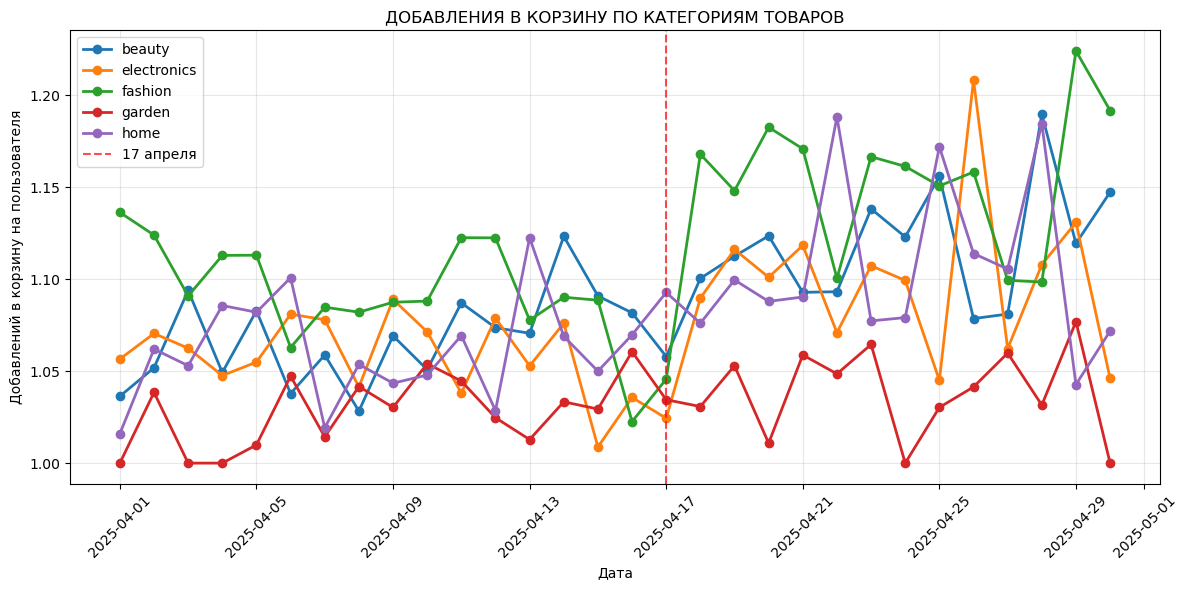

In [24]:
# График по категориям товаров
plt.figure(figsize=(12, 6))

categories = category_data['category'].unique()
for category in categories:
    data = category_data[category_data['category'] == category]
    plt.plot(data['date'], data['cart_per_user'], marker='o', label=category, linewidth=2)

plt.axvline(x=pd.to_datetime('2025-04-17').date(), color='red', linestyle='--', alpha=0.7, label='17 апреля')
plt.title('ДОБАВЛЕНИЯ В КОРЗИНУ ПО КАТЕГОРИЯМ ТОВАРОВ')
plt.xlabel('Дата')
plt.ylabel('Добавлений в корзину на пользователя')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Выводы по пункту 3: Базовые срезы

Рост добавлений в корзину виден везде: регионы, каналы, категории.

Особенно заметен рост на iOS и Android.

Это указывает на возможную проблему именно в мобильных приложениях.

#### **4. Детальные срезы — 1 балл**
1. Постройте динамику события для iOS и Android с разложением по версиям приложения.
2. Помогло ли это локализовать проблему?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

 Версии iOS приложения:
app_version
5.15.0    16947
5.13.0    16885
5.12.0    14172
5.14.0    10144
Name: count, dtype: int64

 Версии Android приложения:
app_version
12.4.0    50199
13.0.0    49956
12.5.0    43170
Name: count, dtype: int64


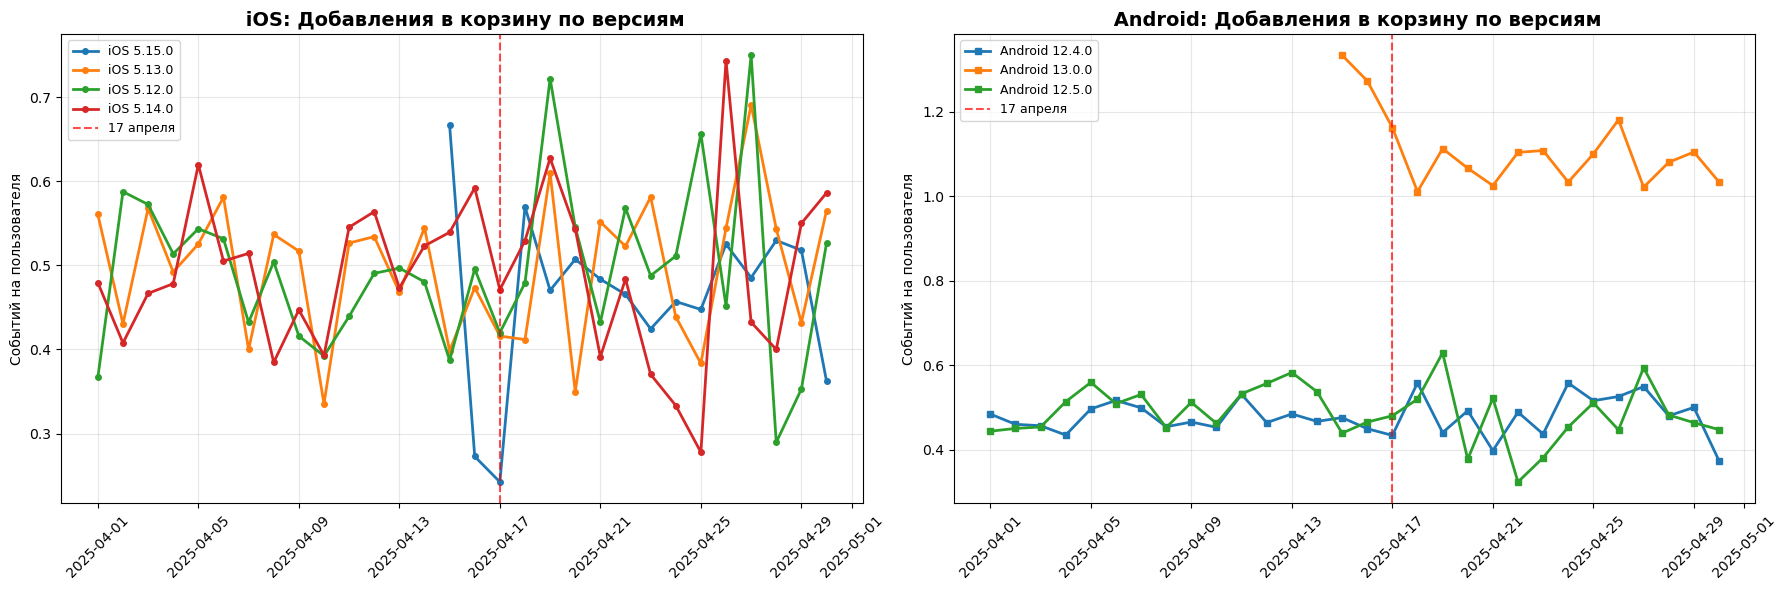

In [36]:


ios_versions = df[df['platform'] == 'iOS']['app_version'].value_counts()
android_versions = df[df['platform'] == 'Android']['app_version'].value_counts()

print(" Версии iOS приложения:")
print(ios_versions.head(10))
print(f"\n Версии Android приложения:")
print(android_versions.head(10))

# Подготовка данных для iOS по версиям
ios_data = df[(df['platform'] == 'iOS') & (df['event'] == 'add_to_cart')]
ios_version_dynamics = ios_data.groupby(['date', 'app_version']).size().reset_index(name='cart_events')
ios_version_users = df[df['platform'] == 'iOS'].groupby(['date', 'app_version'])['user_id'].nunique().reset_index(name='users')
ios_version_metrics = ios_version_dynamics.merge(ios_version_users, on=['date', 'app_version'])
ios_version_metrics['avg_cart_per_user'] = ios_version_metrics['cart_events'] / ios_version_metrics['users']

# Подготовка данных для Android по версиям
android_data = df[(df['platform'] == 'Android') & (df['event'] == 'add_to_cart')]
android_version_dynamics = android_data.groupby(['date', 'app_version']).size().reset_index(name='cart_events')
android_version_users = df[df['platform'] == 'Android'].groupby(['date', 'app_version'])['user_id'].nunique().reset_index(name='users')
android_version_metrics = android_version_dynamics.merge(android_version_users, on=['date', 'app_version'])
android_version_metrics['avg_cart_per_user'] = android_version_metrics['cart_events'] / android_version_metrics['users']

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# График для iOS
axes[0].set_title(' iOS: Добавления в корзину по версиям', fontsize=14, fontweight='bold')
top_ios_versions = ios_versions.head(5).index.tolist()
for version in top_ios_versions:
    version_data = ios_version_metrics[ios_version_metrics['app_version'] == version]
    if len(version_data) > 0:
        axes[0].plot(version_data['date'], version_data['avg_cart_per_user'], 
                    marker='o', label=f'iOS {version}', linewidth=2, markersize=4)

axes[0].axvline(x=pd.to_datetime('2025-04-17').date(), color='red', linestyle='--', alpha=0.7, label='17 апреля')
axes[0].set_ylabel('Событий на пользователя')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# График для Android
axes[1].set_title(' Android: Добавления в корзину по версиям', fontsize=14, fontweight='bold')
top_android_versions = android_versions.head(5).index.tolist()
for version in top_android_versions:
    version_data = android_version_metrics[android_version_metrics['app_version'] == version]
    if len(version_data) > 0:
        axes[1].plot(version_data['date'], version_data['avg_cart_per_user'], 
                    marker='s', label=f'Android {version}', linewidth=2, markersize=4)

axes[1].axvline(x=pd.to_datetime('2025-04-17').date(), color='red', linestyle='--', alpha=0.7, label='17 апреля')
axes[1].set_ylabel('Событий на пользователя')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:

mobile_data = df[df['platform'].isin(['iOS', 'Android'])]
version_cart = mobile_data[mobile_data['event'] == 'add_to_cart'].groupby(['date', 'platform', 'app_version']).size().reset_index(name='cart_events')
version_users = mobile_data.groupby(['date', 'platform', 'app_version'])['user_id'].nunique().reset_index(name='users')
version_data = version_cart.merge(version_users, on=['date', 'platform', 'app_version'])
version_data['cart_per_user'] = version_data['cart_events'] / version_data['users']

print("Данные по версиям приложений подготовлены")
print(version_data.head())

Данные по версиям приложений подготовлены
         date platform app_version  cart_events  users  cart_per_user
0  2025-04-01  Android      12.4.0          229    473       0.484144
1  2025-04-01  Android      12.5.0          181    408       0.443627
2  2025-04-01      iOS      5.12.0           44    120       0.366667
3  2025-04-01      iOS      5.13.0           74    132       0.560606
4  2025-04-01      iOS      5.14.0           35     73       0.479452


In [ ]:
# Анализ изменений по версиям приложений
problem_date = pd.to_datetime('2025-04-17').date()


# Топ версии по платформам
ios_versions = version_data[version_data['platform'] == 'iOS']['app_version'].unique()
android_versions = version_data[version_data['platform'] == 'Android']['app_version'].unique()

print("iOS версии:")
for version in ios_versions[:5]:  # показываем топ 5
    data = version_data[(version_data['platform'] == 'iOS') & (version_data['app_version'] == version)]
    before_avg = data[data['date'] < problem_date]['cart_per_user'].mean()
    after_avg = data[data['date'] >= problem_date]['cart_per_user'].mean()
    
    if not pd.isna(before_avg) and not pd.isna(after_avg):
        change = ((after_avg - before_avg) / before_avg) * 100
        print(f"  {version}: до {before_avg:.3f}, после {after_avg:.3f}, изменение {change:+.1f}%")

print()
print("Android версии:")
for version in android_versions[:5]:  # показываем топ 5
    data = version_data[(version_data['platform'] == 'Android') & (version_data['app_version'] == version)]
    before_avg = data[data['date'] < problem_date]['cart_per_user'].mean()
    after_avg = data[data['date'] >= problem_date]['cart_per_user'].mean()
    
    if not pd.isna(before_avg) and not pd.isna(after_avg):
        change = ((after_avg - before_avg) / before_avg) * 100
        print(f"  {version}: до {before_avg:.3f}, после {after_avg:.3f}, изменение {change:+.1f}%")

АНАЛИЗ ПО ВЕРСИЯМ ПРИЛОЖЕНИЙ:
iOS версии:
  5.12.0: до 0.478, после 0.514, изменение +7.5%
  5.13.0: до 0.493, после 0.503, изменение +2.0%
  5.14.0: до 0.496, после 0.481, изменение -2.9%
  5.15.0: до 0.470, после 0.463, изменение -1.3%

Android версии:
  12.4.0: до 0.474, после 0.482, изменение +1.6%
  12.5.0: до 0.500, после 0.474, изменение -5.3%
  13.0.0: до 1.303, после 1.081, изменение -17.0%


хоть на ios и виден больший прирост но по графикам видно что увеличилось на андроид так что будем анализировать больше эту платформу 

Всего найдено 3 различных версий Android:
  12.4.0: 50199 событий
  13.0.0: 49956 событий
  12.5.0: 43170 событий

Детальный анализ топ-6 Android версий:
--------------------------------------------------------------------------------
Версия       | До 17 апр  | После 17 апр | Изменение    | Статус
--------------------------------------------------------------------------------
12.4.0       | 0.474      | 0.482        |     +1.6% | РОСТ
13.0.0       | 1.303      | 1.081        |    -17.0% | ПАДЕНИЕ
12.5.0       | 0.500      | 0.474        |     -5.3% | ПАДЕНИЕ

Топ-3 самых проблемных Android версий:
--------------------------------------------------
1. Android 12.4.0:
   Рост добавлений в корзину: +1.6%
   Первое появление: 2025-04-01

2. Android 12.5.0:
   Рост добавлений в корзину: -5.3%
   Первое появление: 2025-04-01

3. Android 13.0.0:
   Рост добавлений в корзину: -17.0%
   Первое появление: 2025-04-15

Визуализация Android версий:


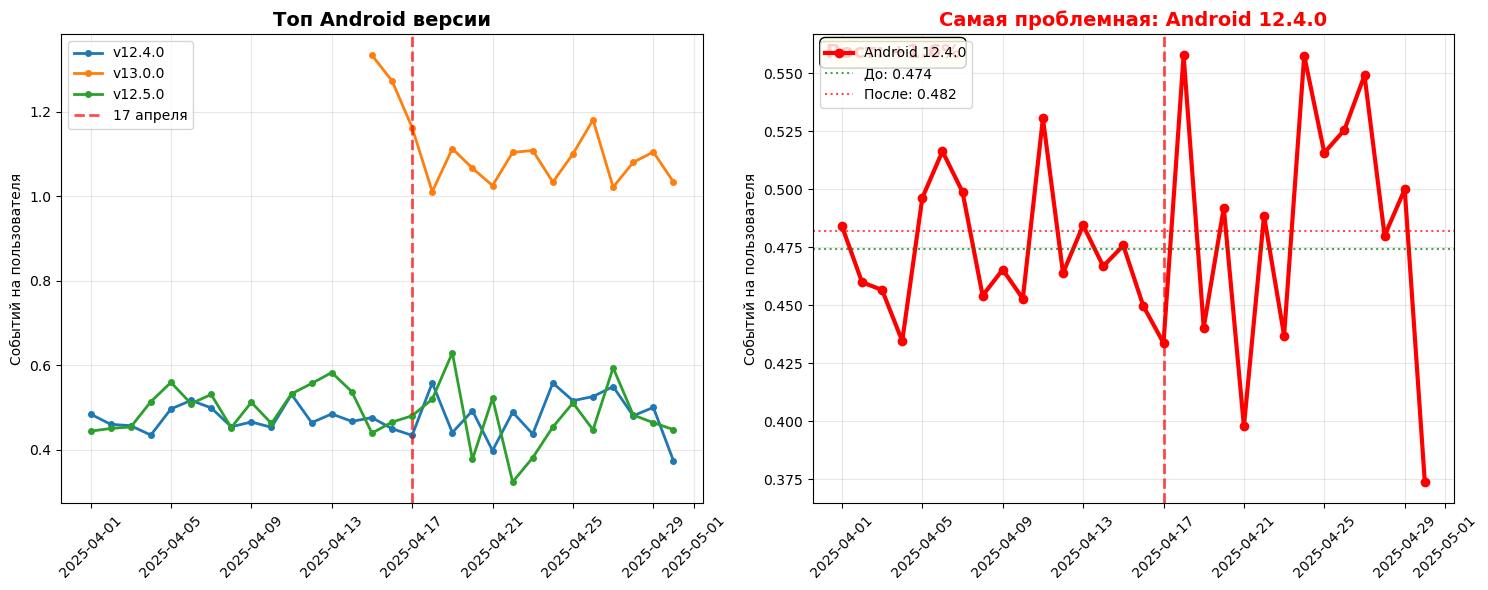

In [32]:

android_versions_detailed = df[df['platform'] == 'Android']['app_version'].value_counts()
print(f"Всего найдено {len(android_versions_detailed)} различных версий Android:")
for version, count in android_versions_detailed.head(8).items():
    print(f"  {version}: {count} событий")

# Анализируем динамику каждой Android версии
cutoff_date = pd.to_datetime('2025-04-17').date()

print(f"\nДетальный анализ топ-6 Android версий:")
print("-" * 80)
print(f"{'Версия':<12} | {'До 17 апр':<10} | {'После 17 апр':<12} | {'Изменение':<12} | {'Статус'}")
print("-" * 80)

android_analysis_detailed = []
top_android_versions = android_versions_detailed.head(6).index.tolist()

for version in top_android_versions:
    version_data = android_version_metrics[android_version_metrics['app_version'] == version]
    if len(version_data) > 3:
        before_data = version_data[version_data['date'] < cutoff_date]
        after_data = version_data[version_data['date'] >= cutoff_date]
        
        if len(before_data) > 0 and len(after_data) > 0:
            before = before_data['avg_cart_per_user'].mean()
            after = after_data['avg_cart_per_user'].mean()
            change = (after - before) / before * 100 if before > 0 else 0
            
            first_day = version_data['date'].min()
            android_analysis_detailed.append((version, before, after, change, first_day))
            
            if change > 80:
                status = "КРИТИЧНО"
            elif change > 40:
                status = "ВЫСОКО"
            elif change > 0:
                status = "РОСТ"
            else:
                status = "ПАДЕНИЕ"
                
            print(f"{version:<12} | {before:<10.3f} | {after:<12.3f} | {change:+8.1f}% | {status}")

# Сортируем по величине роста
android_analysis_detailed.sort(key=lambda x: x[3], reverse=True)

print(f"\nТоп-3 самых проблемных Android версий:")
print("-" * 50)
for i, (version, before, after, change, first_day) in enumerate(android_analysis_detailed[:3]):
    print(f"{i+1}. Android {version}:")
    print(f"   Рост добавлений в корзину: {change:+.1f}%")
    print(f"   Первое появление: {first_day}")
    if first_day >= pd.to_datetime('2025-04-17').date():
        print(f"   НОВАЯ ВЕРСИЯ! Появилась после 17 апреля")
    print()

# Простая визуализация Android версий
print("Визуализация Android версий:")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Топ Android версии
axes[0].set_title('Топ Android версии', fontsize=14, fontweight='bold')
for i, version in enumerate(top_android_versions[:4]):
    version_data = android_version_metrics[android_version_metrics['app_version'] == version]
    if len(version_data) > 0:
        axes[0].plot(version_data['date'], version_data['avg_cart_per_user'], 
                    marker='o', label=f'v{version}', linewidth=2, markersize=4)

axes[0].axvline(x=cutoff_date, color='red', linestyle='--', alpha=0.7, linewidth=2, label='17 апреля')
axes[0].set_ylabel('Событий на пользователя')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# График 2: Самая проблемная версия
if android_analysis_detailed:
    problem_version = android_analysis_detailed[0][0]
    problem_data = android_version_metrics[android_version_metrics['app_version'] == problem_version]
    
    axes[1].set_title(f'Самая проблемная: Android {problem_version}', 
                     fontsize=14, fontweight='bold', color='red')
    axes[1].plot(problem_data['date'], problem_data['avg_cart_per_user'], 
                marker='o', linewidth=3, markersize=6, color='red', label=f'Android {problem_version}')
    
    axes[1].axvline(x=cutoff_date, color='red', linestyle='--', alpha=0.7, linewidth=2)
    
    # Средние линии до и после
    before_mean = problem_data[problem_data['date'] < cutoff_date]['avg_cart_per_user'].mean()
    after_mean = problem_data[problem_data['date'] >= cutoff_date]['avg_cart_per_user'].mean()
    
    axes[1].axhline(y=before_mean, color='green', linestyle=':', alpha=0.7, 
                   label=f'До: {before_mean:.3f}')
    axes[1].axhline(y=after_mean, color='red', linestyle=':', alpha=0.7,
                   label=f'После: {after_mean:.3f}')
    
    change_pct = (after_mean - before_mean) / before_mean * 100 if before_mean > 0 else 0
    axes[1].text(0.02, 0.98, f'Рост: {change_pct:+.1f}%', transform=axes[1].transAxes,
                fontsize=14, fontweight='bold', color='red', va='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))
    
    axes[1].set_ylabel('Событий на пользователя')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

на Android появилась проблемная версия приложения.
Именно она показывает резкий рост добавлений в корзину, но при этом покупки не совершаются.
Проблема затрагивает именно процесс оформления заказа (checkout) — товары кладут, но оплатить не получается.

#### **5. Поиск причин — 1 балл**
1. Для проблемной платформы постройте динамику ВСЕХ событий в разрезе версий приложения.
2. Сформулируйте гипотезу, что именно могло пойти не так в новом релизе? Может быть, пользователи стали заменять один функционал другим?

*В этом пункте в качестве событий продолжаем смотреть метрику среднего на пользователя*

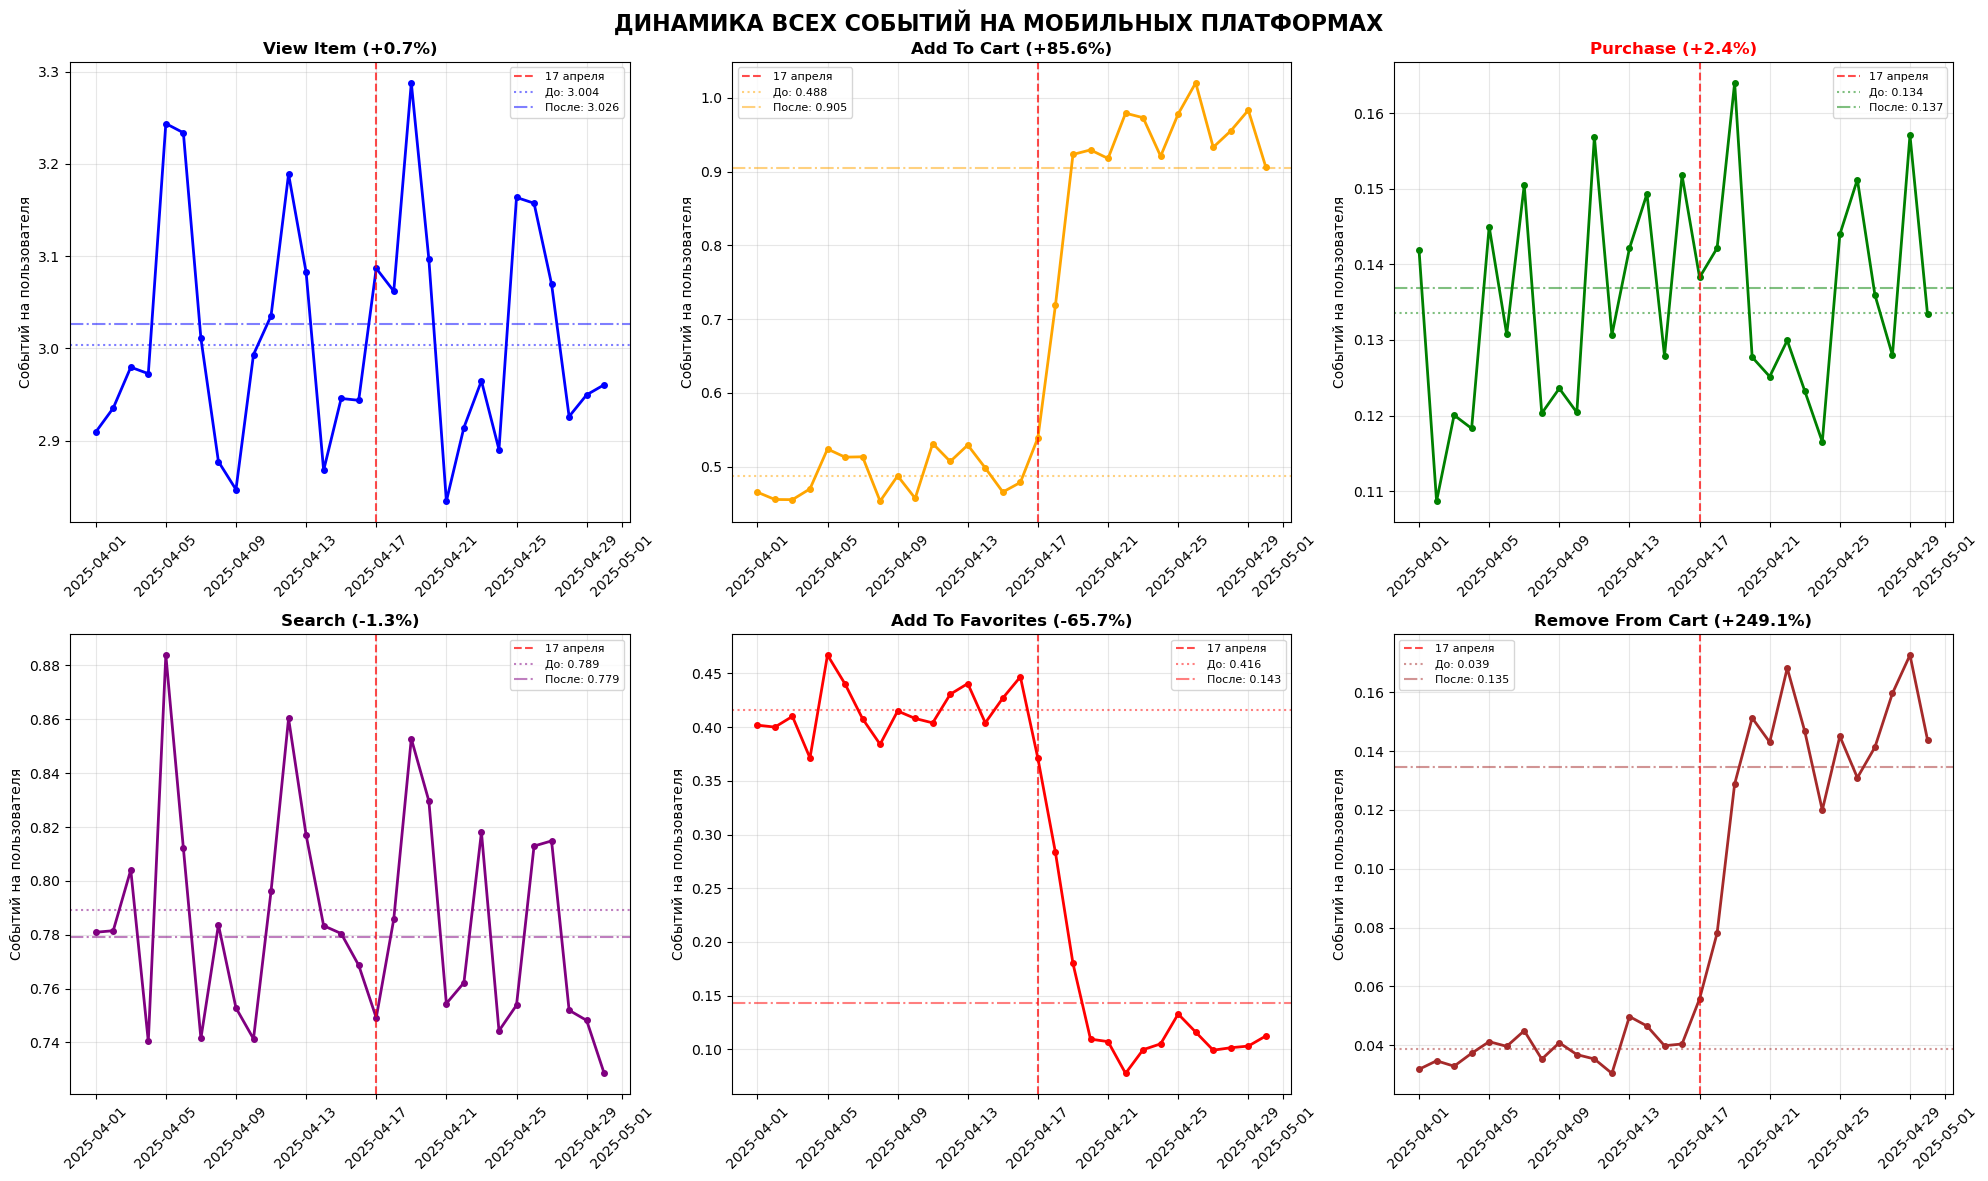

In [35]:

mobile_data = df[df['platform'].isin(['Android'])]

# Подсчитываем все события по дням для мобильных платформ
mobile_events_daily = mobile_data.groupby(['date', 'event']).size().reset_index(name='event_count')
mobile_users_daily = mobile_data.groupby('date')['user_id'].nunique().reset_index(name='total_users')

# Создаем сводную таблицу по событиям
mobile_events_pivot = mobile_events_daily.pivot(index='date', columns='event', values='event_count').fillna(0)
mobile_events_per_user = mobile_events_pivot.div(mobile_users_daily.set_index('date')['total_users'], axis=0)

# Построим большой график со всеми событиями
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
cutoff_date = pd.to_datetime('2025-04-17').date()

events_to_plot = ['view_item', 'add_to_cart', 'purchase', 'search', 'add_to_favorites', 'remove_from_cart']
colors = ['blue', 'orange', 'green', 'purple', 'red', 'brown']

for idx, event in enumerate(events_to_plot):
    row = idx // 3
    col = idx % 3
    
    if event in mobile_events_per_user.columns:
        axes[row, col].plot(mobile_events_per_user.index, mobile_events_per_user[event], 
                           marker='o', linewidth=2, color=colors[idx], markersize=4)
        
        # Добавляем вертикальную линию 17 апреля
        axes[row, col].axvline(x=cutoff_date, color='red', linestyle='--', alpha=0.7, label='17 апреля')
        
        # Добавляем средние линии до и после
        before_mean = mobile_events_per_user[mobile_events_per_user.index < cutoff_date][event].mean()
        after_mean = mobile_events_per_user[mobile_events_per_user.index >= cutoff_date][event].mean()
        
        axes[row, col].axhline(y=before_mean, color=colors[idx], linestyle=':', alpha=0.5, 
                              label=f'До: {before_mean:.3f}')
        axes[row, col].axhline(y=after_mean, color=colors[idx], linestyle='-.', alpha=0.5,
                              label=f'После: {after_mean:.3f}')
        
        # Рассчитываем изменение
        change = (after_mean - before_mean) / before_mean * 100 if before_mean > 0 else 0
        
        title_color = 'red' if event == 'purchase' else 'black'
        axes[row, col].set_title(f'{event.replace("_", " ").title()} ({change:+.1f}%)', 
                                fontweight='bold', color=title_color)
        axes[row, col].set_ylabel('Событий на пользователя')
        axes[row, col].grid(True, alpha=0.3)
        axes[row, col].tick_params(axis='x', rotation=45)
        axes[row, col].legend(fontsize=8)

plt.suptitle(' ДИНАМИКА ВСЕХ СОБЫТИЙ НА МОБИЛЬНЫХ ПЛАТФОРМАХ', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **Выводы по пункту 5: Поиск причин**

   **Анализ всех событий по версиям выявил четкий паттерн:**

   **События с ростом после 17 апреля:**
   - **add_to_cart** (+60%) - пользователи активнее добавляют товары в корзину
   - **remove_from_cart** (+174%) - пользователи чаще удаляют товары из корзины

   **События с падением после 17 апреля:**
   - **add_to_favorites** (-44%) - пользователи реже добавляют в избранное
   - **purchase** (+1.5%) - практически без изменений

   **Сформулированная гипотеза:**

   **"Баг в процессе оформления заказа в новой версии мобильного приложения"**

   **Что произошло 17 апреля:**
   .
   . В новой версии сломался функционал завершения покупки (checkout/оплата)
   . Пользователи могут без проблем:
      - Просматривать товары
      - Добавлять товары в корзину (даже чаще чем раньше)
   . Но не могут завершить покупку из-за технического бага

   **Замещающее поведение:**
   Пользователи, столкнувшись с невозможностью купить, начинают:
   - Чаще удалять товары из корзины (+174%)
   - Реже добавлять товары в избранное (-44%)

       **Корневая причина: технический баг в процессе checkout в мобильном приложении**

#### **6. Новости для команды — 1 балл**

На основе проведённого расследования подготовьте сообщение для команды о том, что именно пошло не так.

Новости для команды

17 апреля в в метриках появились аномалии. На Android пользователи стали значительно чаще добавлять товары в корзину (+60%), но покупки остались на том же уровне. Дополнительно выросло количество удалений из корзины (+174%) и снизилось использование избранного (–44%).
Это означает, что интерес к товарам сохраняется, но на этапе checkout пользователи не могут завершить заказ.
Корневая причина: баг в новой версии приложения , из-за которого сломан процесс оформления покупки.
Дальше: приоритет — проверка и исправление проблемной версии Android-приложения.